## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from itables import show
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.data.columns import PATIENT_COL, DIAGNOSIS_COL
from src.data.ml_dataset_specs import UCVA_TARGET

from src.modeling.model_inputs import prepare_train_test_model_inputs
from src.modeling.configs import (
    ElasticNetSearchConfig,
    prefix_param_space,
)
from src.modeling.pipelines import (
    make_elasticnet_pipeline, 
    make_log_target_pipeline,
)
from src.modeling.tuning import tune_model
from src.modeling.plots import plot_elasticnet_heatmap


DATA_PATH = PROJECT_ROOT / "data/ml/ucva_exam1_base_2024-11-02.xlsx"

TEST_SIZE = 0.2
RANDOM_STATE = 42

## 2. Train/Test Data Preparation

In [2]:
df = pd.read_excel(DATA_PATH)
df.shape

(399, 80)

In [3]:
inputs = prepare_train_test_model_inputs(
    df=df,
    target_col=UCVA_TARGET,
    group_col=PATIENT_COL,
    exclude_feature_cols=[DIAGNOSIS_COL],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_inputs = inputs.train
test_inputs = inputs.test

## 3. ElasticNet Tuning

In [4]:
search_config = ElasticNetSearchConfig(
    alphas=np.logspace(-4, 2, 100),
    l1_ratios=np.linspace(0.05, 1.0, 20),
)

elasticnet_tuning = tune_model(
    estimator=make_elasticnet_pipeline(),
    param_space=search_config.param_space,
    X=train_inputs.X,
    y=train_inputs.y,
    groups=train_inputs.groups,
    scoring="neg_mean_absolute_error",
    search_type="random",
    n_iter=100,
    random_state=RANDOM_STATE,
    score_tolerance=0.002,
    add_n_selected_features=True,
    treat_sparse_model_as_selector=True,
)

show(elasticnet_tuning.candidates.head(20))
print(elasticnet_tuning.search.best_params_)
print(elasticnet_tuning.search.best_score_)

Loading ITables v2.7.3 from the internet... (need help?)


{'model__l1_ratio': np.float64(0.2), 'model__alpha': np.float64(0.1873817422860385)}
-0.0972080425067698


In [5]:
scoring_configs = {
    "MAE": {
        "scoring": "neg_mean_absolute_error",
        "score_tolerance": 0.002,
    },
    "RMSE": {
        "scoring": "neg_root_mean_squared_error",
        "score_tolerance": 0.002,
    },
    "R²": {
        "scoring": "r2",
        "score_tolerance": 0.02,
    },
}

search_config = ElasticNetSearchConfig(
    alphas=np.concatenate([np.linspace(0.01, 0.09, 9), np.linspace(0.1, 0.5, 9)]),
    l1_ratios=np.concatenate([np.linspace(0.01, 0.04, 4), np.linspace(0.05, 1, 20)]),
)

elasticnet_tuning_results = {}

for scoring_name, scoring_config in scoring_configs.items():
    elasticnet_tuning_results[scoring_name] = tune_model(
        estimator=make_elasticnet_pipeline(),
        param_space=search_config.param_space,
        X=train_inputs.X,
        y=train_inputs.y,
        groups=train_inputs.groups,
        scoring=scoring_config["scoring"],
        search_type="grid",
        score_tolerance=scoring_config["score_tolerance"],
        add_n_selected_features=True,
        treat_sparse_model_as_selector=True,
    )

In [6]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    print(scoring_name)
    print(tuning_result.search.best_params_)
    print(tuning_result.search.best_score_)
    show(tuning_result.candidates.head(20))

MAE
{'model__alpha': np.float64(0.35), 'model__l1_ratio': np.float64(0.1)}
-0.09688739240645748


Loading ITables v2.7.3 from the internet... (need help?)


RMSE
{'model__alpha': np.float64(0.30000000000000004), 'model__l1_ratio': np.float64(0.05)}
-0.17868983004939124


Loading ITables v2.7.3 from the internet... (need help?)


R²
{'model__alpha': np.float64(0.30000000000000004), 'model__l1_ratio': np.float64(0.05)}
0.25418724214876065


Loading ITables v2.7.3 from the internet... (need help?)


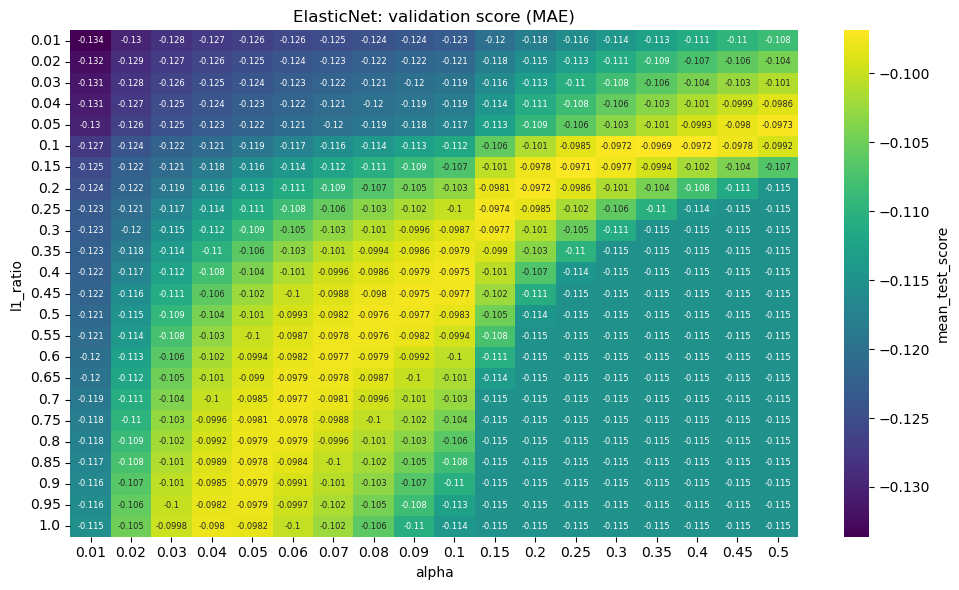

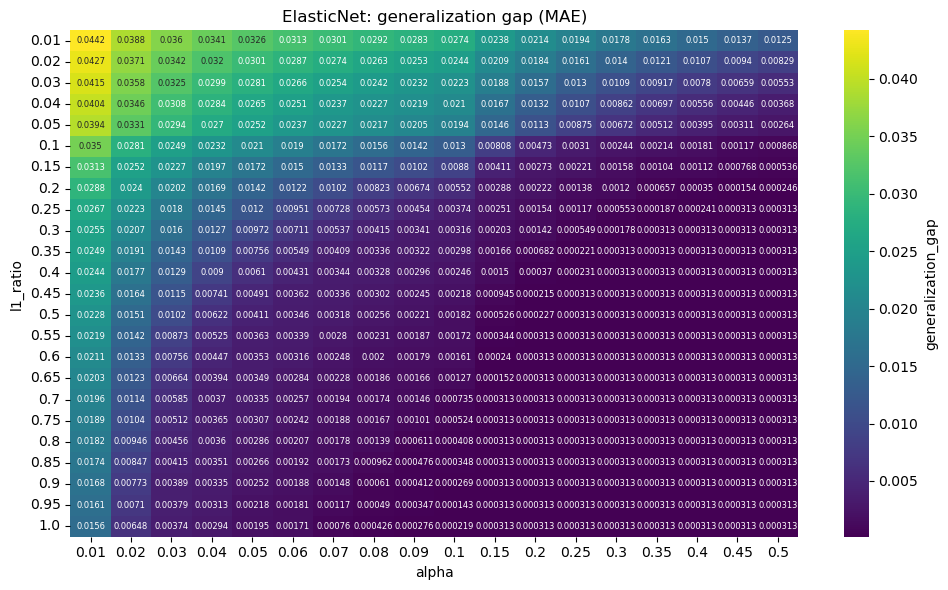

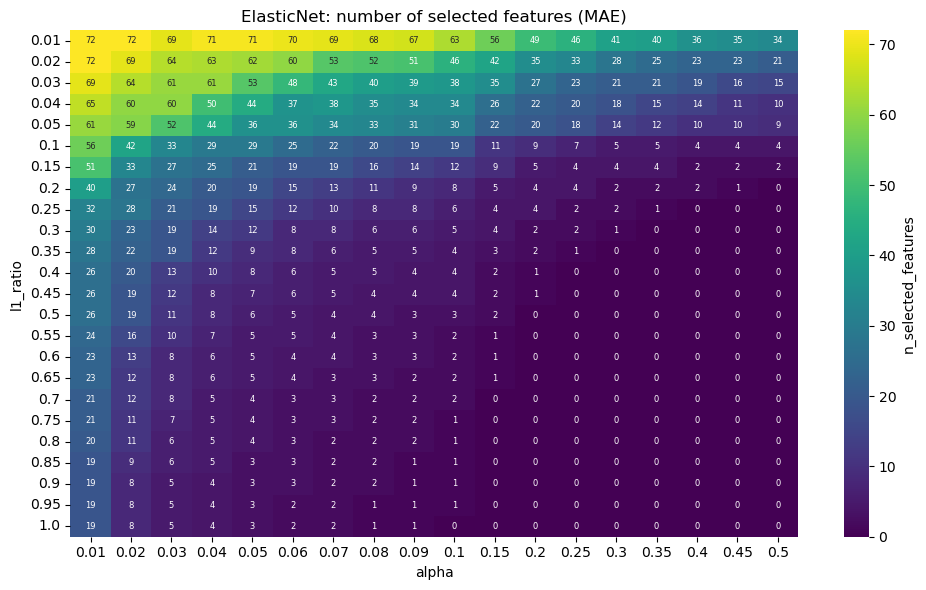

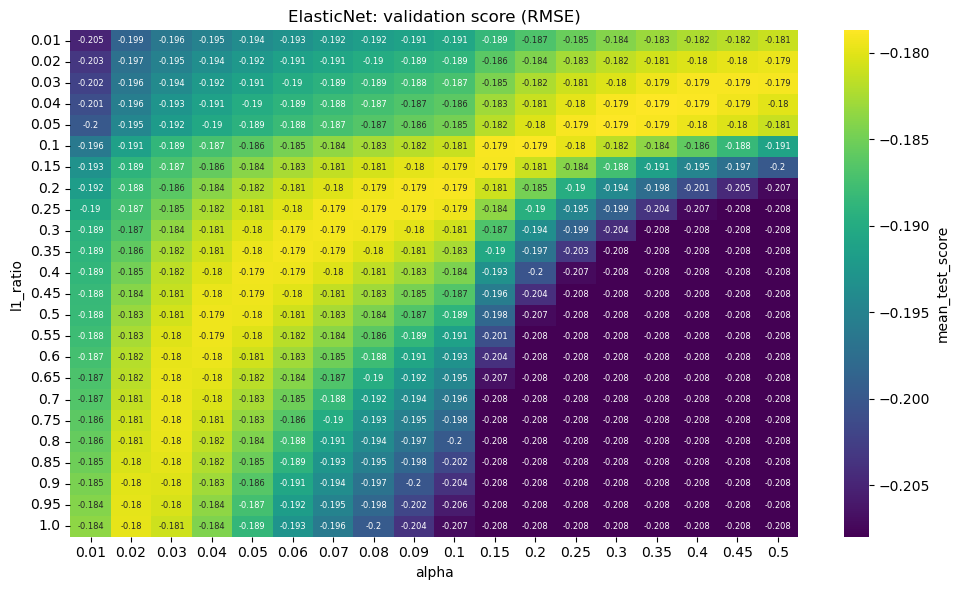

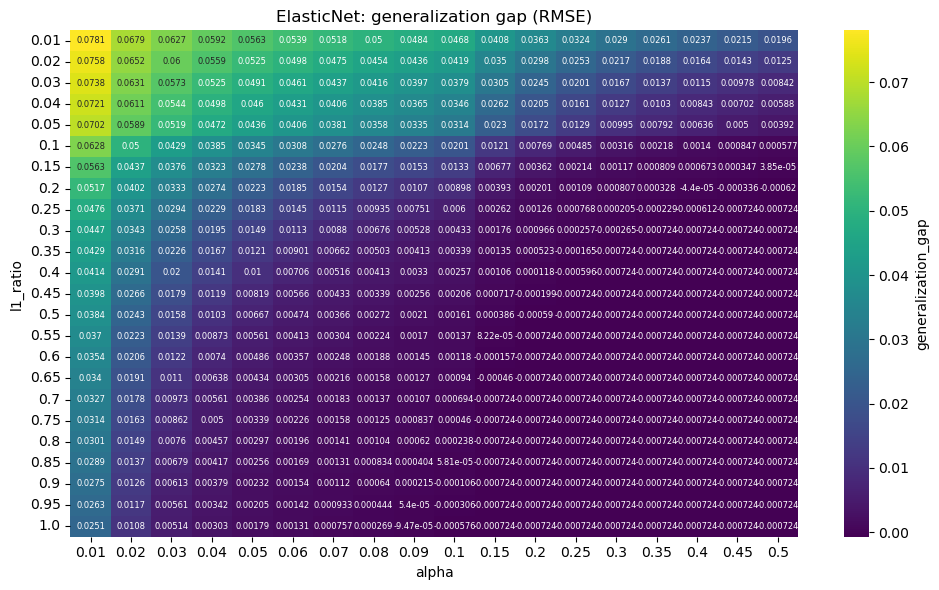

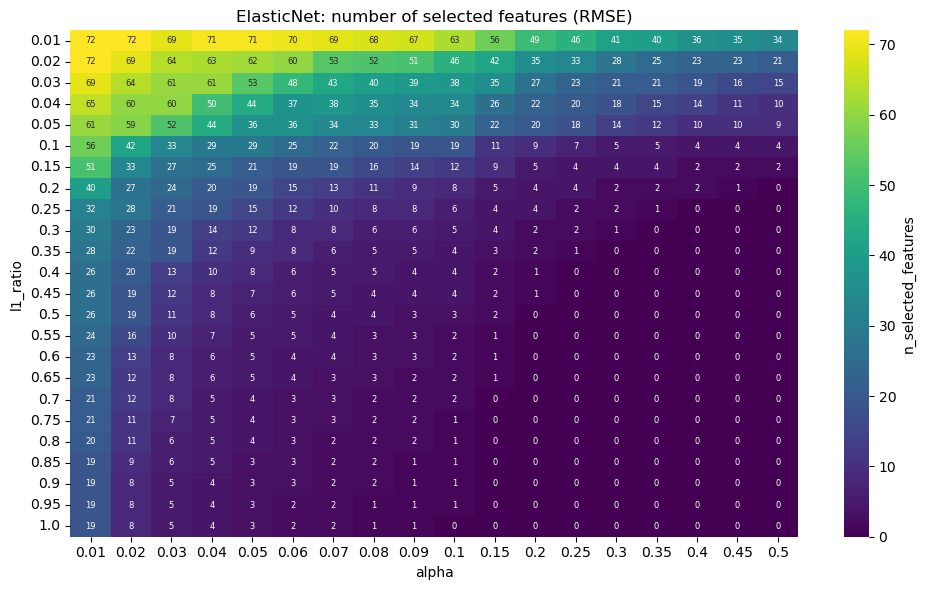

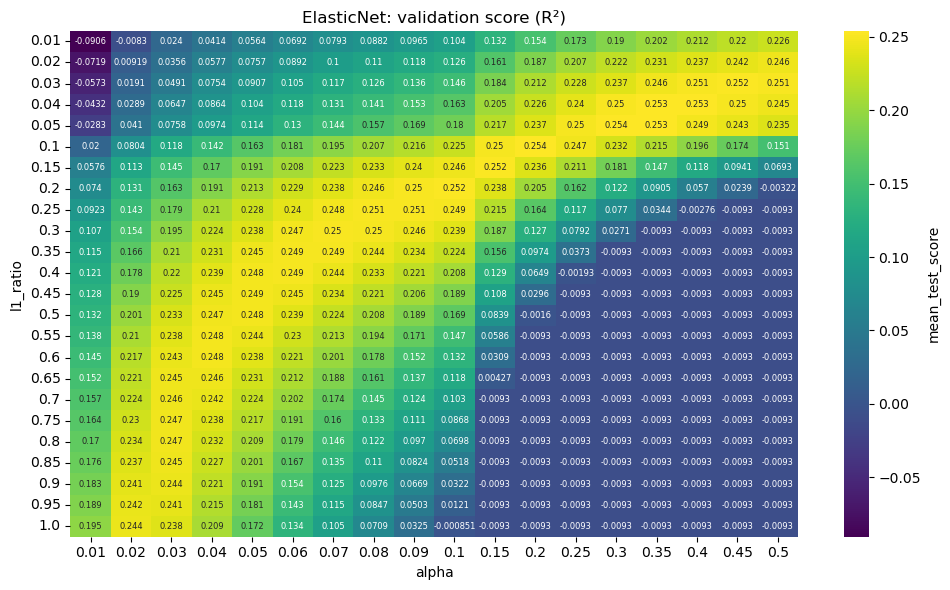

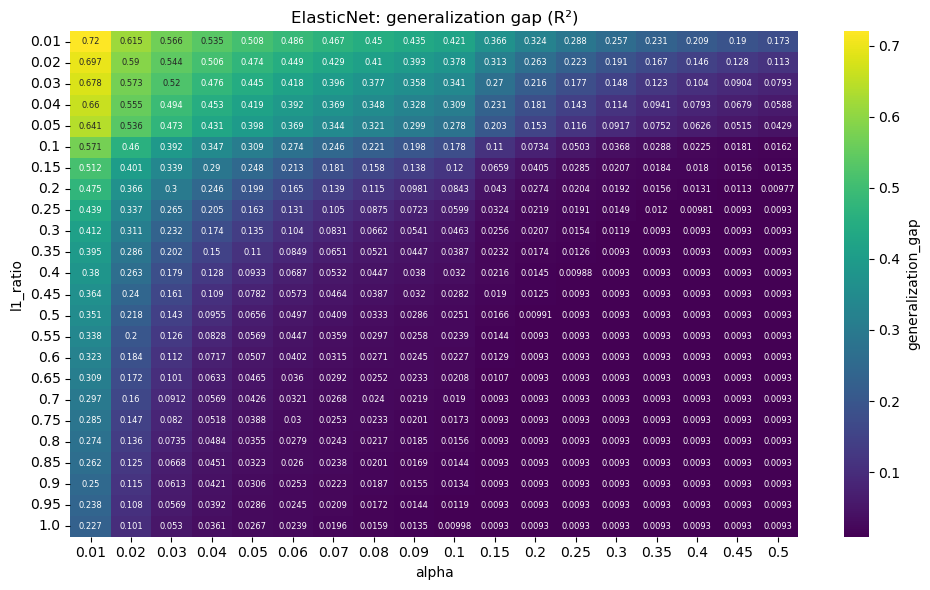

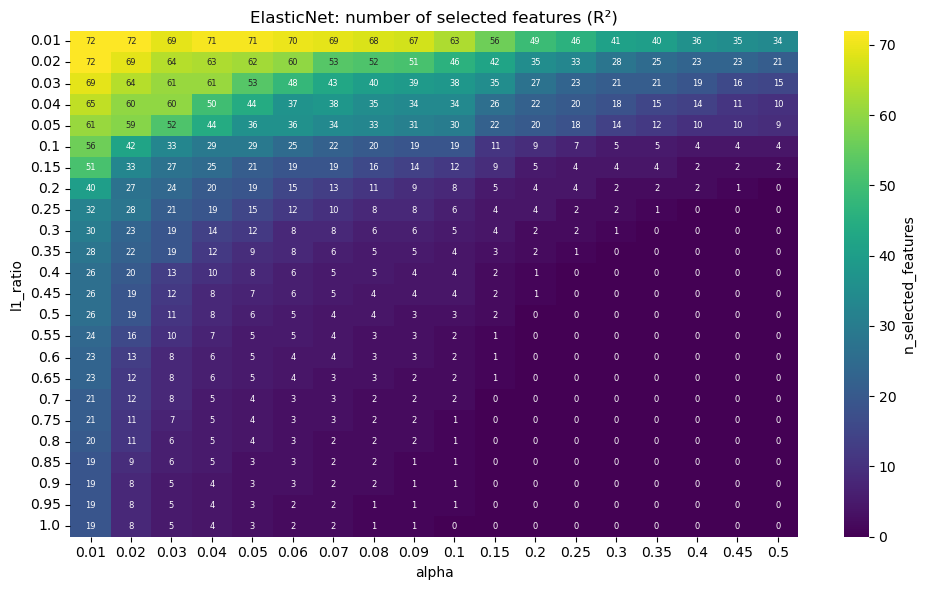

In [7]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    for value_col, title_suffix in [
        ("mean_test_score", "validation score"),
        ("generalization_gap", "generalization gap"),
        ("n_selected_features", "number of selected features"),
    ]:
        fig, ax = plot_elasticnet_heatmap(
            results=tuning_result.results,
            value_col=value_col,
            title=f"ElasticNet: {title_suffix} ({scoring_name})",
        )
        plt.show()

In [8]:
candidate_params = [
    #alpha, l1
    # best candidates based on MAE
    # (0.05, 0.85), 
    # (0.06, 0.70),
    # (0.07, 0.60),
    # (0.08, 0.50),
    # (0.09, 0.45),
    # (0.10, 0.40),
    # (0.15, 0.25),
    (0.20, 0.20),
    # (0.25, 0.15),
    (0.30, 0.10),
    (0,35, 0.10),
    (0.40, 0.10),
    # (0.50, 0.05),

    # best candidates based on R2
    (0.20, 0.10),
]

## 4. ElasticNet Tuning on Stable Feature Core

In [9]:
stable_features = [
    "Рефрактометрія без циклоплегії Sphera",
    "Рефрактометрія циклоплегія Sphera",
    "Рефрактометрія циклоплегія Cylynder",
    "Axial length (mm)",
    "A. C. Depth (mm)",
]

In [10]:
scoring_configs = {
    "MAE": {
        "scoring": "neg_mean_absolute_error",
        "score_tolerance": 0.002,
    },
    "RMSE": {
        "scoring": "neg_root_mean_squared_error",
        "score_tolerance": 0.002,
    },
    "R²": {
        "scoring": "r2",
        "score_tolerance": 0.02,
    },
}

search_config = ElasticNetSearchConfig(
    alphas=np.concatenate([np.linspace(0.01, 0.09, 9), np.linspace(0.1, 0.5, 9)]),
    l1_ratios=np.concatenate([np.linspace(0.01, 0.04, 4), np.linspace(0.05, 1, 20)]),
)

elasticnet_tuning_results = {}

for scoring_name, scoring_config in scoring_configs.items():
    elasticnet_tuning_results[scoring_name] = tune_model(
        estimator=make_elasticnet_pipeline(),
        param_space=search_config.param_space,
        X=train_inputs.X[stable_features],
        y=train_inputs.y,
        groups=train_inputs.groups,
        scoring=scoring_config["scoring"],
        search_type="grid",
        score_tolerance=scoring_config["score_tolerance"],
        add_n_selected_features=True,
        treat_sparse_model_as_selector=True,
    )

In [11]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    print(scoring_name)
    print(tuning_result.search.best_params_)
    print(tuning_result.search.best_score_)
    show(tuning_result.candidates.head(20))

MAE
{'model__alpha': np.float64(0.35), 'model__l1_ratio': np.float64(0.1)}
-0.0965845588527843


Loading ITables v2.7.3 from the internet... (need help?)


RMSE
{'model__alpha': np.float64(0.2), 'model__l1_ratio': np.float64(0.01)}
-0.1733105990202636


Loading ITables v2.7.3 from the internet... (need help?)


R²
{'model__alpha': np.float64(0.2), 'model__l1_ratio': np.float64(0.01)}
0.29732090952874723


Loading ITables v2.7.3 from the internet... (need help?)


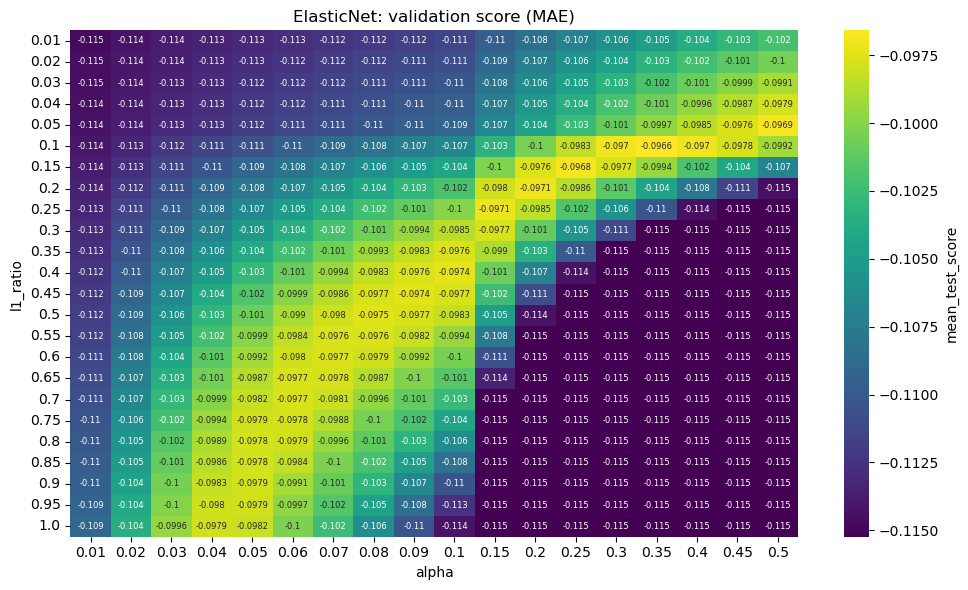

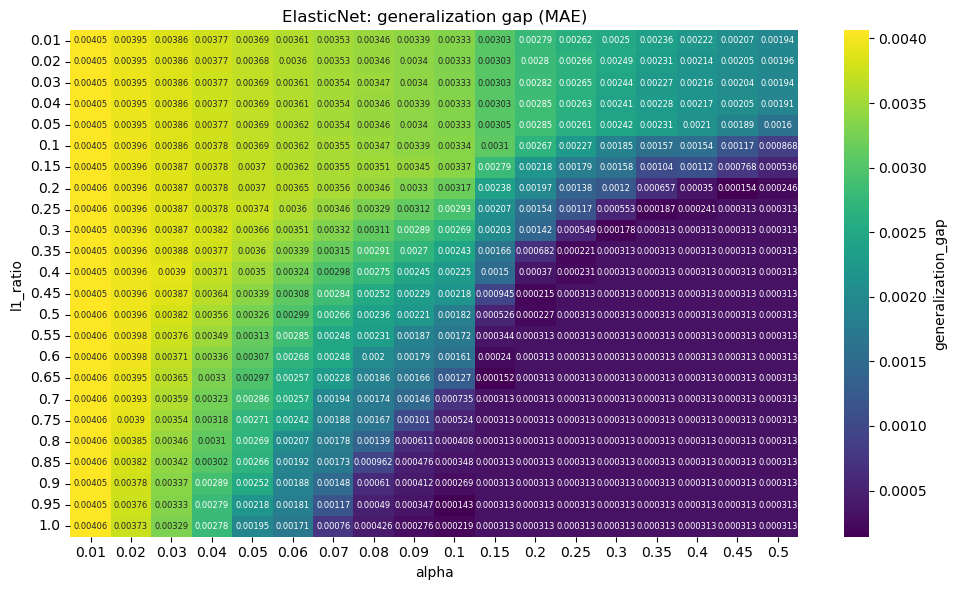

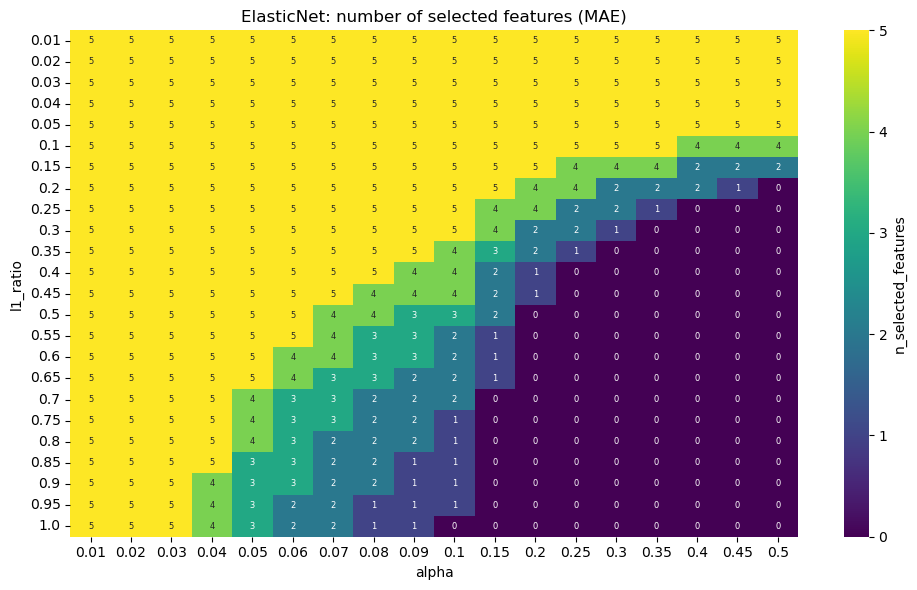

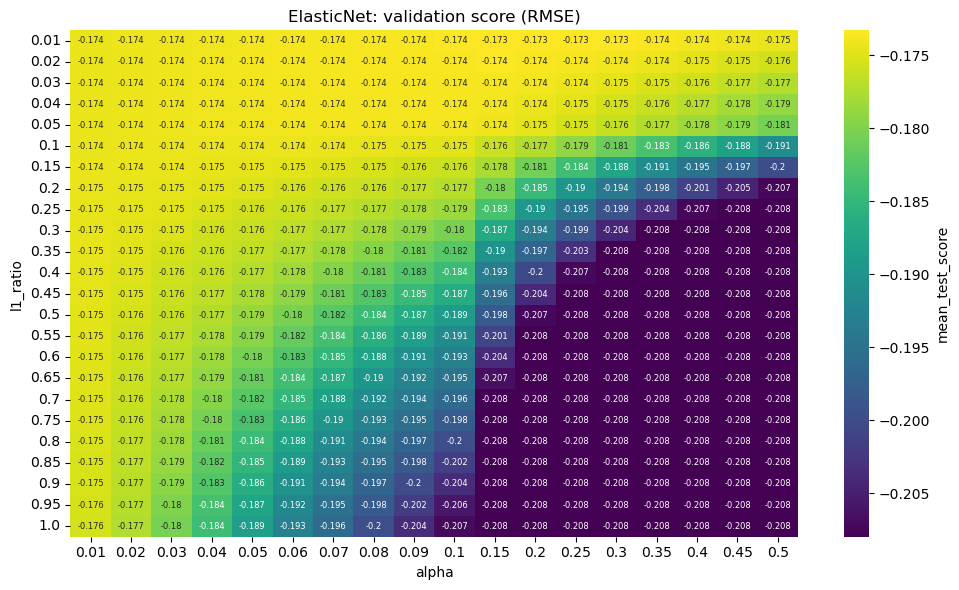

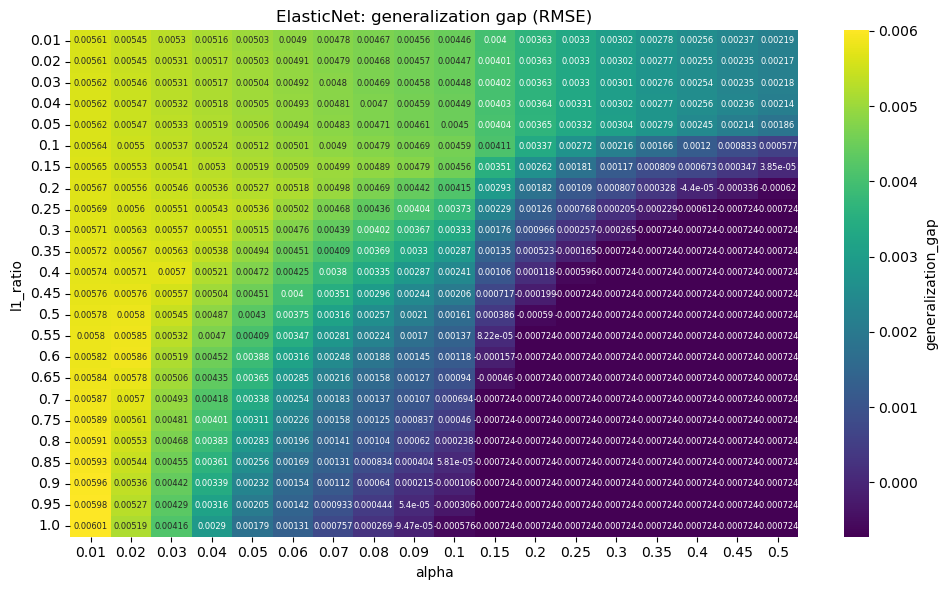

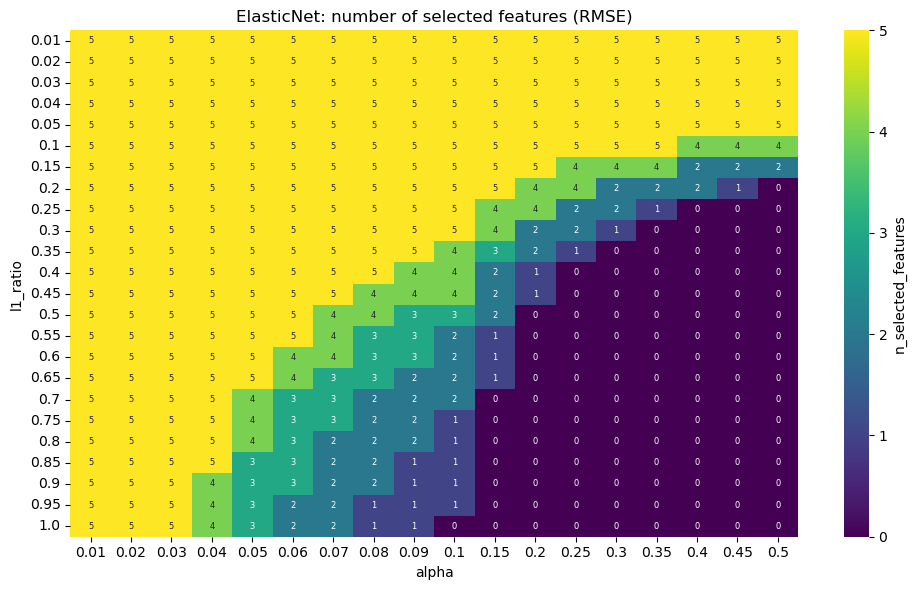

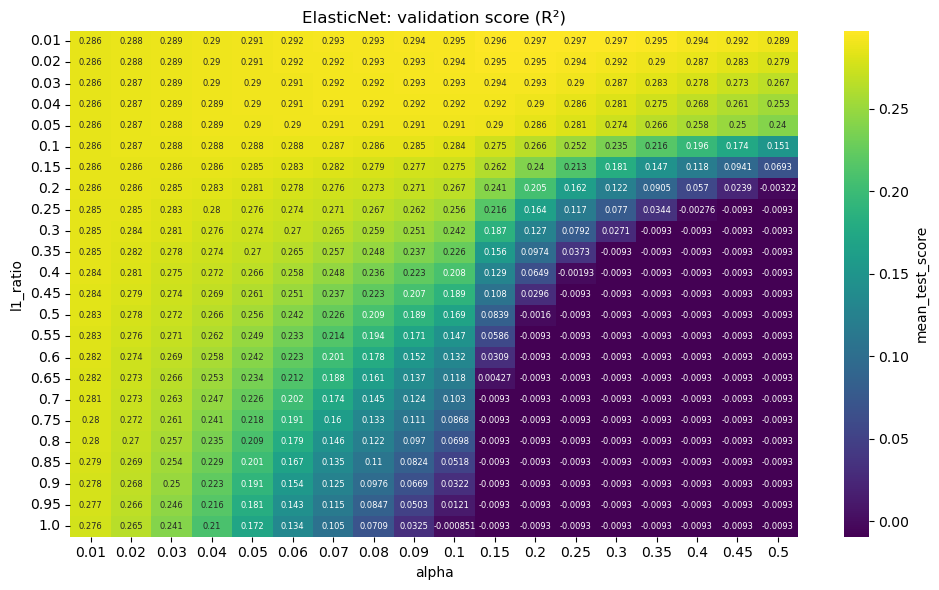

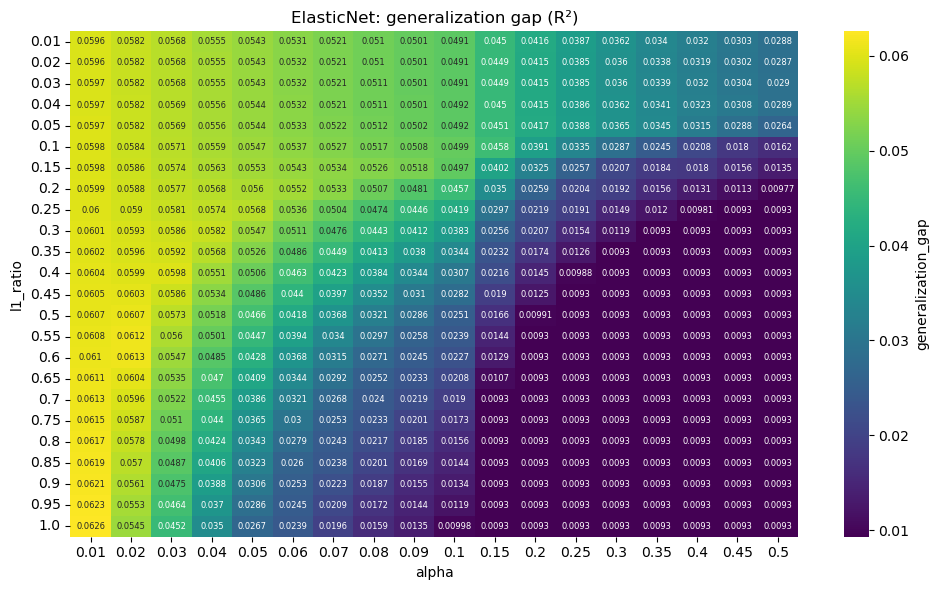

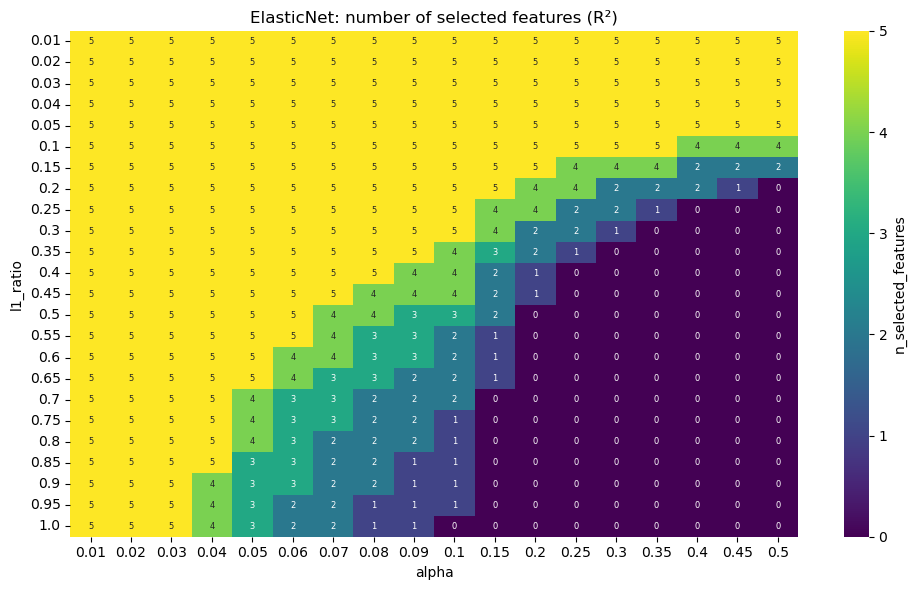

In [12]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    for value_col, title_suffix in [
        ("mean_test_score", "validation score"),
        ("generalization_gap", "generalization gap"),
        ("n_selected_features", "number of selected features"),
    ]:
        fig, ax = plot_elasticnet_heatmap(
            results=tuning_result.results,
            value_col=value_col,
            title=f"ElasticNet: {title_suffix} ({scoring_name})",
        )
        plt.show()

## 5. ElasticNet Tuning with Log-Transformed Target

In [13]:
search_config = ElasticNetSearchConfig(
    alphas=np.logspace(-4, 2, 100),
    l1_ratios=np.linspace(0.05, 1.0, 20),
)

elasticnet_tuning = tune_model(
    estimator=make_log_target_pipeline(make_elasticnet_pipeline()),
    param_space=prefix_param_space(search_config.param_space, prefix="regressor"),
    X=train_inputs.X,
    y=train_inputs.y,
    groups=train_inputs.groups,
    scoring="neg_mean_absolute_error",
    search_type="random",
    n_iter=100,
    random_state=RANDOM_STATE,
    score_tolerance=0.002,
    add_n_selected_features=True,
    treat_sparse_model_as_selector=True,
)

show(elasticnet_tuning.candidates.head(20))
print(elasticnet_tuning.search.best_params_)
print(elasticnet_tuning.search.best_score_)

Loading ITables v2.7.3 from the internet... (need help?)


{'regressor__model__l1_ratio': np.float64(0.05), 'regressor__model__alpha': np.float64(0.1873817422860385)}
-0.07201260617337017


In [14]:
scoring_configs = {
    "MAE": {
        "scoring": "neg_mean_absolute_error",
        "score_tolerance": 0.002,
    },
    "RMSE": {
        "scoring": "neg_root_mean_squared_error",
        "score_tolerance": 0.002,
    },
    "R²": {
        "scoring": "r2",
        "score_tolerance": 0.02,
    },
}

search_config = ElasticNetSearchConfig(
    alphas=np.concatenate([np.linspace(0.01, 0.09, 9), np.linspace(0.1, 0.5, 9)]),
    l1_ratios=np.concatenate([np.linspace(0.01, 0.04, 4), np.linspace(0.05, 1, 20)]),
)

elasticnet_tuning_results = {}

for scoring_name, scoring_config in scoring_configs.items():
    elasticnet_tuning_results[scoring_name] = tune_model(
        estimator=make_log_target_pipeline(make_elasticnet_pipeline()),
        param_space=prefix_param_space(search_config.param_space, prefix="regressor"),
        X=train_inputs.X,
        y=train_inputs.y,
        groups=train_inputs.groups,
        scoring=scoring_config["scoring"],
        search_type="grid",
        score_tolerance=scoring_config["score_tolerance"],
        add_n_selected_features=True,
        treat_sparse_model_as_selector=True,
    )

In [15]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    print(scoring_name)
    print(tuning_result.search.best_params_)
    print(tuning_result.search.best_score_)
    show(tuning_result.candidates.head(20))

MAE
{'regressor__model__alpha': np.float64(0.2), 'regressor__model__l1_ratio': np.float64(0.1)}
-0.07194345185240993


Loading ITables v2.7.3 from the internet... (need help?)


RMSE
{'regressor__model__alpha': np.float64(0.02), 'regressor__model__l1_ratio': np.float64(0.01)}
-0.18175587324595135


Loading ITables v2.7.3 from the internet... (need help?)


R²
{'regressor__model__alpha': np.float64(0.15000000000000002), 'regressor__model__l1_ratio': np.float64(0.1)}
0.1965811603964312


Loading ITables v2.7.3 from the internet... (need help?)


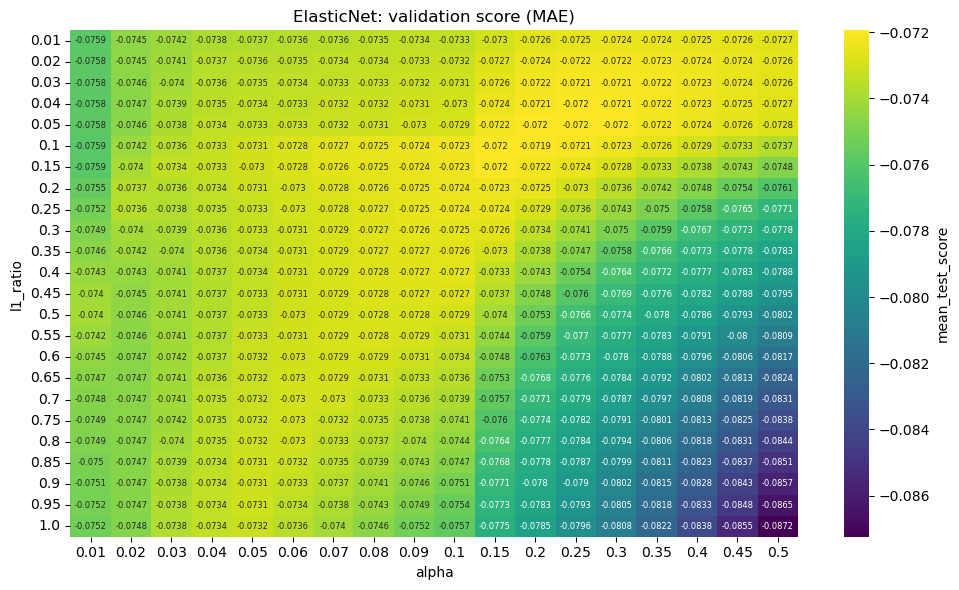

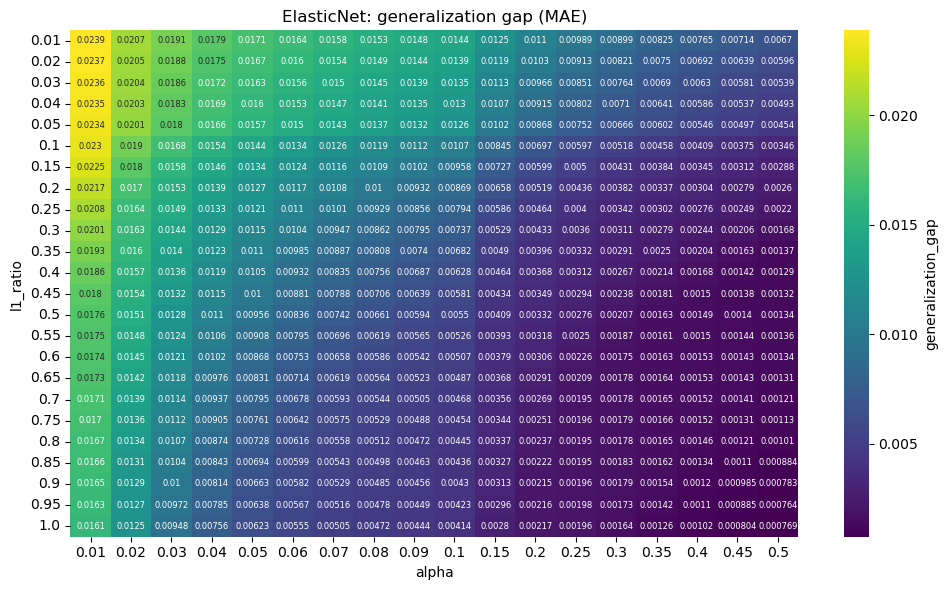

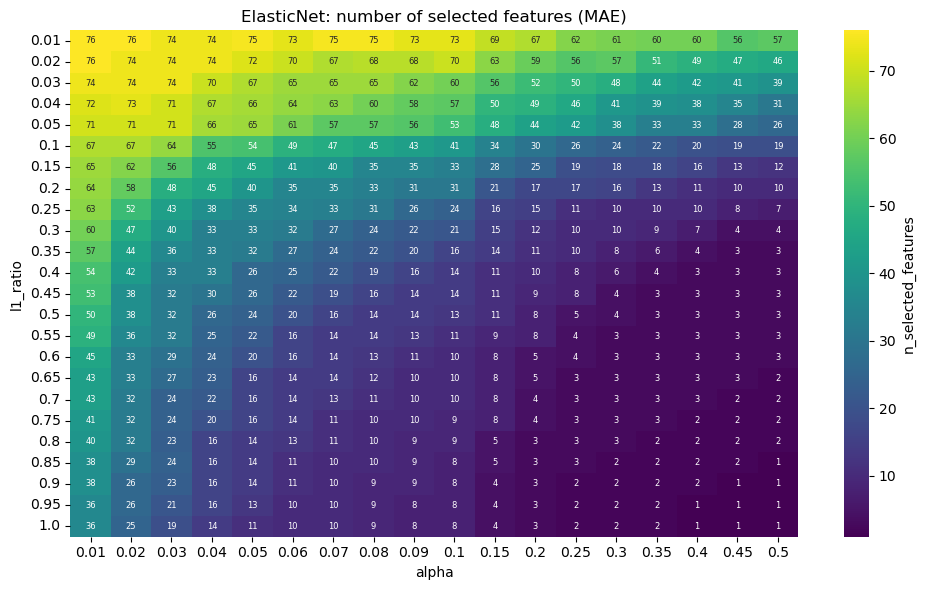

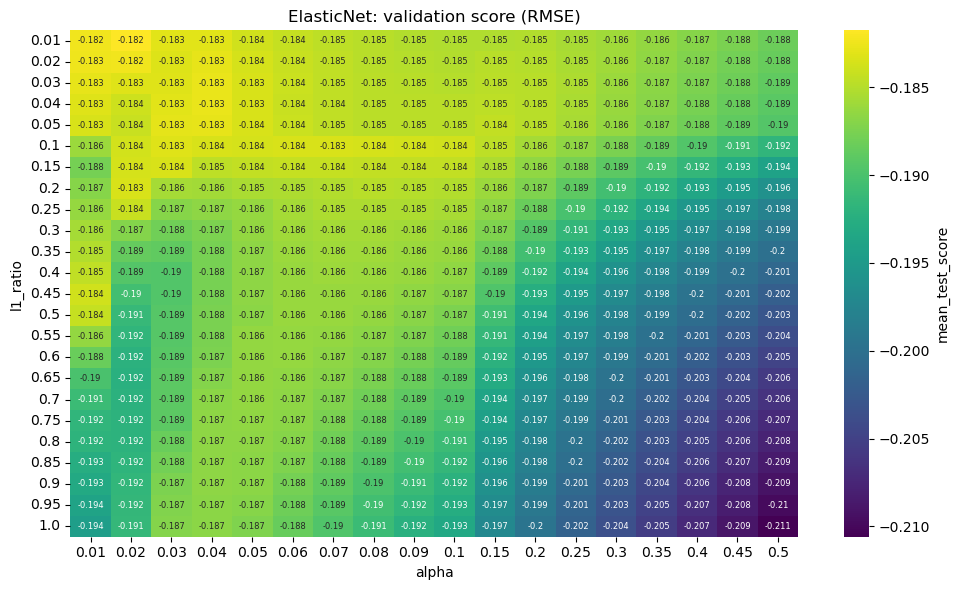

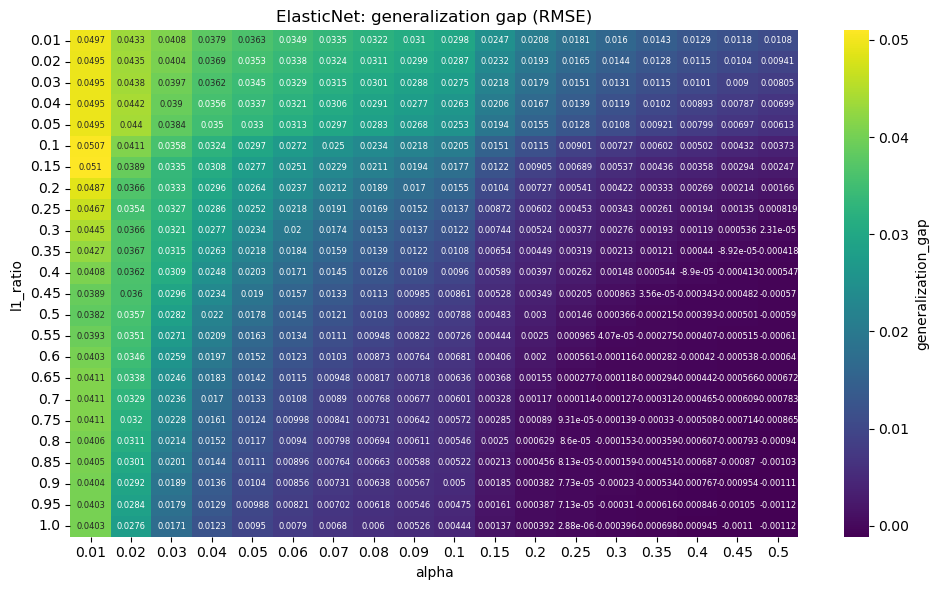

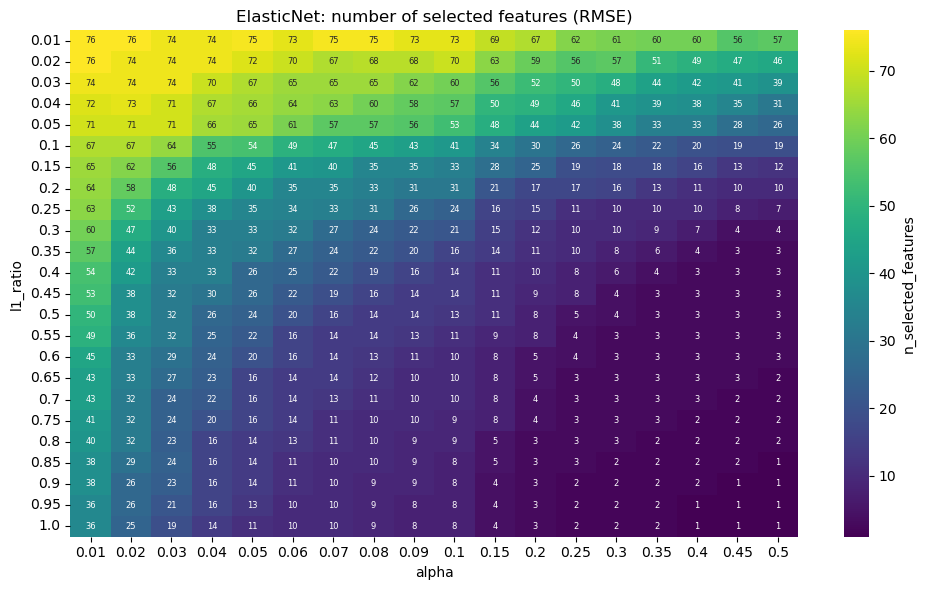

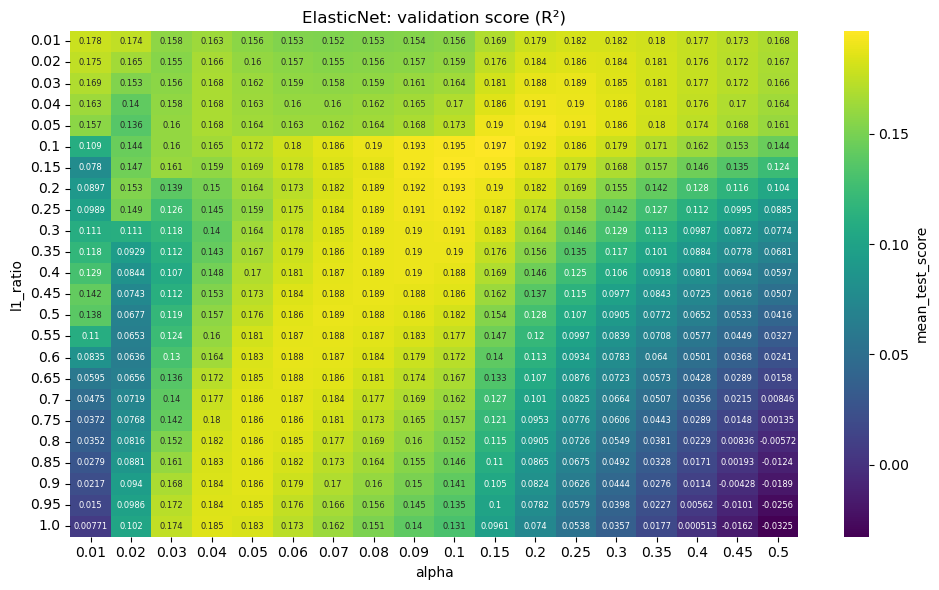

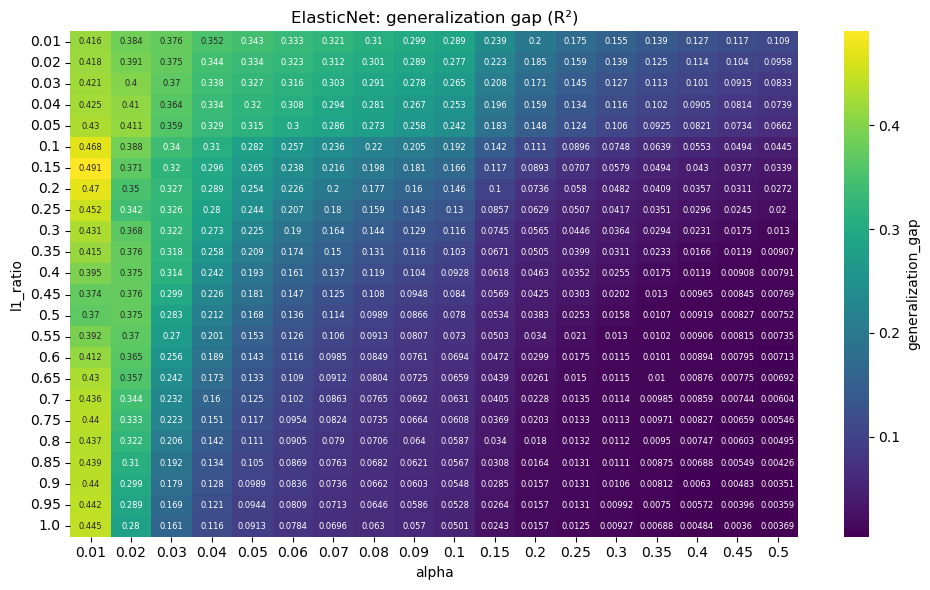

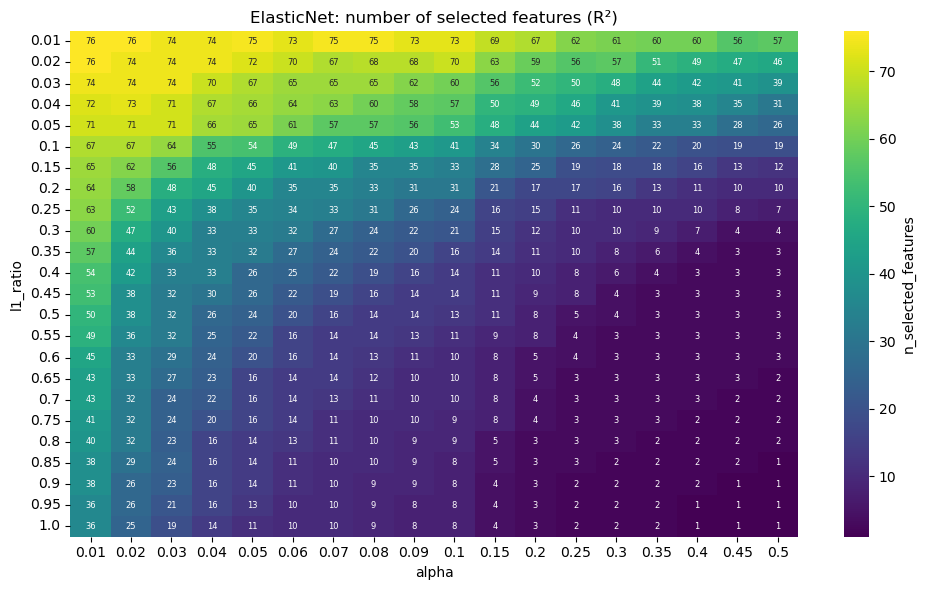

In [16]:
for scoring_name, tuning_result in elasticnet_tuning_results.items():
    for value_col, title_suffix in [
        ("mean_test_score", "validation score"),
        ("generalization_gap", "generalization gap"),
        ("n_selected_features", "number of selected features"),
    ]:
        fig, ax = plot_elasticnet_heatmap(
            results=tuning_result.results,
            value_col=value_col,
            title=f"ElasticNet: {title_suffix} ({scoring_name})",
        )
        plt.show()